In [9]:
import torch
import torch.nn as nn
from torch.optim import SGD
import numpy as np
import matplotlib.pyplot as plt

Suppose one has data that consists of an independent vector and a dependent vector $x_i$ and $y_i$ ($i$ is the ith value in the data set). For example:

* $x_i$ is the height of the $i$ th person, and $y_i$ is their weight (predict weight using height)
* $x_i$ is a picture of a handwritten digit, and $y_i$ is the digit itself (predict numbers from hand written numbers)
* $x_i$ is a CT scan of a patient, and $y_i$ are the corresponding pixels corresponding to tumours

The goal of a neural network is as follows. Define a function $f$ that depends on parameters $a$ that makes predictions

$$\hat{y_i} =f(x_i;a)$$

One wants to make $\hat{y_i}$ (the predictions) and $y_i$ (the true values) as close as possible by modifying the values of $a$. What does as close as possible mean? This depends on the task. In general, one defines a similarity function (or **Loss** function) $L(y,\hat{y})$. The more similar all the $y_i$ 's and $\hat{y_i}$ 's are, the smaller $L$ should be. For example 1 above, this could be as simple as 

$$L(y,\hat{y}) = \sum_i(y_i-\hat{y_i})^2$$

$$A_2 A_1 = B$$

where $B$ is a $2 \times 1$ matrix. So really the function is $f(x) = Bx$

## How can one use this simplicity of linear algebra but have advanced models?

**The Crux of Machine Learning**: This lies in so-called activation functions, which add ever-so-slight non-linearities to a sequence of matrix transformations. Instead of the transformation

$$\text{Old Model}: \hspace{5mm} f(x) = A_2 A_1 x$$

consider instead

$$\text{New Model}: \hspace{5mm} f_2(x) = A_2 R(A_1 x)$$

where $R$ is an element-wise operator defined by

$$R(x) = \begin{cases}x & x>0 \\ 0&  x \leq 0 \end{cases}$$

So $R$ is the identity function if $x>0$ but sets values equal to zero if $x$ is less than zero. This is **so-close** to being a linear operator, but it is not. 

In [10]:
x = torch.tensor([[4,6,2,-1,6,2,5],[1,6,2,-6,5,-3,5]])
x

tensor([[ 4,  6,  2, -1,  6,  2,  5],
        [ 1,  6,  2, -6,  5, -3,  5]])

In [11]:
R = nn.ReLU()
R(x)

tensor([[4, 6, 2, 0, 6, 2, 5],
        [1, 6, 2, 0, 5, 0, 5]])

All the negative values have been replaced with 0 as defined above

In [12]:
x = torch.linspace(-3, 3, 100)
y = R(x)

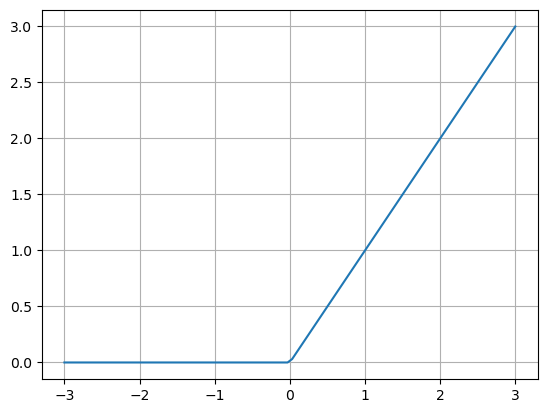

In [13]:
plt.plot(x.numpy(), y.numpy())
plt.grid()
plt.show()

How much better does the model do with this simple adjustment? (The model in the 'basic network.ipynb' file)

In [14]:
class MyNeuralNet2(nn.Module):
    def __init__(self):
        super().__init__()
        self.Matrix1 = nn.Linear(2,8,bias=False)
        self.Matrix2 = nn.Linear(8,1,bias=False)
        self.R = nn.ReLU()
    def forward(self,x):
        x = self.R(self.Matrix1(x))
        x = self.Matrix2(x)
        return x.squeeze()

In [15]:
def train_model(x,y,f, n_epochs=50):
    opt = SGD(f.parameters(), lr=0.001)
    L = nn.MSELoss()

    # Train model
    losses = []
    for _ in range(n_epochs):
        opt.zero_grad() # flush previous epoch's gradient
        loss_value = L(f(x), y) #compute loss
        loss_value.backward() # compute gradient
        opt.step() # Perform iteration using gradient above
        losses.append(loss_value.item())
    return f, losses

In [16]:
x = torch.tensor([[6,2],[5,2],[1,3],[7,6]]).float()
y = torch.tensor([1,5,2,5]).float()
f2 = MyNeuralNet2()

# Train model
f2, losses2 = train_model(x,y,f2, n_epochs=5000)

In [17]:
y

tensor([1., 5., 2., 5.])

In [19]:
f2(x)

tensor([2.6571, 2.5970, 1.8851, 5.3172], grad_fn=<SqueezeBackward0>)

In [20]:
class MyNeuralNet3(nn.Module):
    def __init__(self):
        super().__init__()
        self.Matrix1 = nn.Linear(2,80, bias=False)
        self.Matrix2 = nn.Linear(80,1, bias=False)
        self.R = nn.ReLU()
    def forward(self,x):
        x = self.R(self.Matrix1(x))
        x = self.Matrix2(x)
        return x.squeeze()

In [21]:
x = torch.tensor([[6,2],[5,2],[1,3],[7,6]]).float()
y = torch.tensor([1,5,2,5]).float()
f3 = MyNeuralNet3()

# Train model
f3, losses3 = train_model(x,y,f3, n_epochs=5000)

In [22]:
y

tensor([1., 5., 2., 5.])

In [23]:
f3(x)

tensor([1.8865, 3.7227, 1.9512, 5.1874], grad_fn=<SqueezeBackward0>)

Closer, but still not exact. The model can be made better by introducing other parameters:

$$f(x) = A_2 R(A_1x + b_1) + b_2$$

where $b_1$ and $b_2$ are vectors added to each of the linear transformations.

$$\text{Old Model}: \hspace{5mm} f_3(x) = A_2 R(A_1 x) \hspace{8mm} \text{$A_2$ is 1x80 and $A_1$ is 80x2}$$

$$\text{New Model}: \hspace{5mm} f_4(x) = A_2 R(A_1 x+b_1)+b_2  \hspace{8mm} \text{$A_2$ is 1x80 and $A_1$ is 80x2}$$

In [25]:
class MyNeuralNet4(nn.Module):
    def __init__(self):
        super().__init__()
        self.Matrix1 = nn.Linear(2,80)
        self.Matrix2 = nn.Linear(80,1)
        self.R = nn.ReLU()
    def forward(self,x):
        x = self.R(self.Matrix1(x))
        x = self.Matrix2(x)
        return x.squeeze()

In [26]:
x = torch.tensor([[6,2],[5,2],[1,3],[7,6]]).float()
y = torch.tensor([1,5,2,5]).float()
f4 = MyNeuralNet4()

# Train model
f4, losses4 = train_model(x,y,f4, n_epochs=5000)

In [27]:
y

tensor([1., 5., 2., 5.])

In [28]:
f4(x)

tensor([1.5519, 4.3040, 2.0272, 5.0321], grad_fn=<SqueezeBackward0>)

Better, but its still not that close to $y$, however. What another matrix was added in the middle?

$$\text{Old Model}: \hspace{5mm} f_4(x) = A_2 R(A_1 x+b_1)+b_2  \hspace{8mm} \text{$A_2$ is 1x80 and $A_1$ is 80x2}$$

$$\text{New Model}: \hspace{5mm} f_5(x) = A_3 R(A_2 R(A_1 x+b_1)+b_2)  \hspace{8mm} \text{$A_3$ is 1x80 and $A_2$ is 80x80 and $A_1$ is 80x2}$$

In [29]:
class MyNeuralNet5(nn.Module):
    def __init__(self):
        super().__init__()
        self.Matrix1 = nn.Linear(2,80)
        self.Matrix2 = nn.Linear(80,80)
        self.Matrix3 = nn.Linear(80,1)
        self.R = nn.ReLU()
    def forward(self,x):
        x = self.R(self.Matrix1(x))
        x = self.R(self.Matrix2(x))
        x = self.Matrix3(x)
        return x.squeeze()

x = torch.tensor([[6,2],[5,2],[1,3],[7,6]]).float()
y = torch.tensor([1,5,2,5]).float()
f5 = MyNeuralNet5()

# Train model
f5, losses5 = train_model(x,y,f5, n_epochs=5000)

In [30]:
y

tensor([1., 5., 2., 5.])

In [31]:
f5(x)

tensor([1.0007, 4.9998, 2.0001, 5.0003], grad_fn=<SqueezeBackward0>)

It's predicting y almost exactly (albeit by overfitting, no doubt)

A general "sequential" neural network can be expressed as

$$f(x) = \underset{i=1}{\overset{n}{\Huge{\kappa}}} R_i(A_ix+b_i)$$

where $\underset{i=1}{\overset{n}{\Huge{\kappa}}}f_i(x) = f_n \circ f_{n-1} ... \circ f_1(x)$ and the $A_i$ are matrices and the $b_i$ are bias vectors. Typically the $R_i$ are the same for all the layers (typically ReLU) **except** for the last layer, where $R_i$ is just the identity function

* **Note**: In clever architectures, like convolutional neural networks, the $A_i$'s become sparse matrices (most of there parameters are fixed to equal zero).